# Imports and Starting




In [ ]:
# --- 1. Environment & Setup ---
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/URECA/URECA Research Init/WorM-main"

import os, torch, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from argparse import Namespace
from IPython.display import display
from torch.utils.data import DataLoader
from src.model import WM_Model
from src.data.dataset import Color_Orientation_Size_Gap_Conjunction_Change_Detection_Dataset

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Load Model & Data ---
MODEL_PATH = "./Trained_Models/LSTM/LSTM_96/model.pt"
DATA_PATH = "./wm_bench_data"
BATCH_SIZE = 64

ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
config = Namespace(**ckpt["config"]) if isinstance(ckpt["config"], dict) else ckpt["config"]
model = WM_Model(config, device).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=False)
model.eval()

cd_variants = [("Color", "CD_Color_Task"), ("Orientation", "CD_Orientation_Task"),
               ("Size", "CD_Size_Task"), ("Gap", "CD_Gap_Task"), ("Conjunction", "CD_Conj_Task")]
cd_loaders = {}

for variant, task_name in cd_variants:
    # write=False stops Drive overwriting, num_workers=0 stops the Colab crashes
    ds = Color_Orientation_Size_Gap_Conjunction_Change_Detection_Dataset(
        data_path=DATA_PATH, max_seq_len=20, variant=variant, rs_img_size=32, split="test", write=False)
    cd_loaders[task_name] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# --- 3. Core Utility Functions ---
# --- 3. Core Utility Functions ---

def reset_all_seeds(seed=42):
    """Reset RNG states so perturbation-based evaluations are reproducible."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def plot_trial_sequence(stim_batch, seq_len, ri=None, trial_idx=0, title="Trial Sequence"):
    """
    Plots Memory, Retention, and Probe frames for a single trial.
    If retention_interval = 0, it only plots Memory and Probe.
    """
    length = int(seq_len[trial_idx].item())

    if ri is not None:
        retention_interval = int(ri[trial_idx].item())
    else:
        retention_interval = max(length - 2, 0)

    if retention_interval > 0 and length > 2:
        retention_t = 1
        frames_to_plot = [0, retention_t, length - 1]
        labels = [
            "Memory Array (t=0)",
            f"Retention Frame (t={retention_t})",
            f"Probe Array (t={length - 1})"
        ]
    else:
        frames_to_plot = [0, length - 1]
        labels = [
            "Memory Array (t=0)",
            f"Probe Array (t={length - 1})"
        ]

    fig, axes = plt.subplots(1, len(frames_to_plot), figsize=(4 * len(frames_to_plot), 3))

    if len(frames_to_plot) == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=14)

    for ax, t, label in zip(axes, frames_to_plot, labels):
        img = stim_batch[trial_idx, t].detach().permute(1, 2, 0).cpu().numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def evaluate_model(model, dataloaders, condition_name, perturbation_fn=None, seed=42, save_outputs=True):
    """
    Evaluates the model and returns a DataFrame of raw trial records.

    Saves:
    - task and CD variant
    - set size
    - retention interval
    - condition name
    - correctness
    - final prediction
    - target label

    If perturbation_fn is provided, it is applied to stim_batch before inference.
    """

    reset_all_seeds(seed)
    model.eval()

    records = []

    with torch.no_grad():
        for task_name, loader in dataloaders.items():
            variant_name = task_name.replace("CD_", "").replace("_Task", "")

            for batch in tqdm(loader, desc=f"{condition_name}: {task_name}", leave=False):
                if task_name == "CD_Conj_Task":
                    stim_batch, resp_batch, seq_len, ri, set_size, _ = batch
                else:
                    stim_batch, resp_batch, seq_len, ri, set_size = batch

                stim_batch = stim_batch.to(device)
                resp_batch = resp_batch.to(device)

                # Keep indexing tensors on the same device as model outputs.
                seq_len_device = seq_len.to(device)
                final_t = seq_len_device - 1
                batch_indices = torch.arange(stim_batch.size(0), device=device)

                if perturbation_fn is not None:
                    stim_batch = perturbation_fn(stim_batch, seq_len_device)

                out, _, _, _, _ = model(stim_batch, task_name, seq_len_device)

                pred = torch.round(torch.sigmoid(out)).squeeze(-1)

                final_preds = pred[batch_indices, final_t]
                final_targets = resp_batch[batch_indices, final_t]

                corrects = (final_preds == final_targets).detach().cpu().numpy().astype(int)
                final_preds_cpu = final_preds.detach().cpu().numpy().astype(int)
                final_targets_cpu = final_targets.detach().cpu().numpy().astype(int)

                for i in range(stim_batch.size(0)):
                    record = {
                        "task": task_name,
                        "variant": variant_name,
                        "set_size": int(set_size[i].item()),
                        "retention_interval": int(ri[i].item()),
                        "condition": condition_name,
                        "correct": int(corrects[i])
                    }

                    if save_outputs:
                        record["pred"] = int(final_preds_cpu[i])
                        record["target"] = int(final_targets_cpu[i])

                    records.append(record)

    return pd.DataFrame(records)


def replace_retention_with_static(stim_batch, seq_len, value_min=0.0, value_max=1.0):
    """
    Replace only retention-phase frames with random static.

    For Change Detection:
    - t = 0 is memory array
    - t = 1 to seq_len-2 are retention frames
    - t = seq_len-1 is probe array
    """
    noisy = stim_batch.clone()

    for i in range(stim_batch.shape[0]):
        length = int(seq_len[i].item())

        retention_start = 1
        retention_end = length - 1

        if retention_end > retention_start:
            static_noise = torch.empty_like(noisy[i, retention_start:retention_end])
            static_noise.uniform_(value_min, value_max)
            noisy[i, retention_start:retention_end] = static_noise

    return noisy

Mounted at /content/drive
/content/drive/MyDrive/URECA/URECA Research Init/WorM-main
Using device: cuda
Getting data for Color_Orientation_Size_Gap_Conjunction_Change_Detection_Color Task
Data already exists. Skipping data generation.
Getting data for Color_Orientation_Size_Gap_Conjunction_Change_Detection_Orientation Task
Data already exists. Skipping data generation.
Getting data for Color_Orientation_Size_Gap_Conjunction_Change_Detection_Size Task
Data already exists. Skipping data generation.
Getting data for Color_Orientation_Size_Gap_Conjunction_Change_Detection_Gap Task
Data already exists. Skipping data generation.
Getting data for Color_Orientation_Size_Gap_Conjunction_Change_Detection_Conjunction Task
Data already exists. Skipping data generation.


# Stage 0

**Clean Baseline VS Random Static Distractors**

**Visualize Clean Baseline**

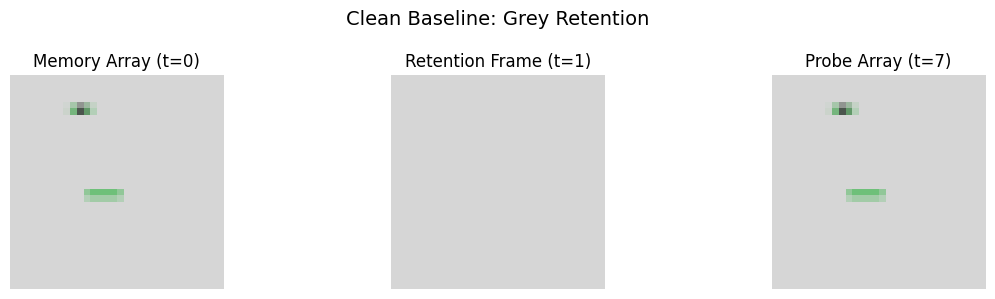

In [ ]:
# 1. Example of Clean Grey Retention Phase
sample_batch = next(iter(cd_loaders["CD_Color_Task"]))
sample_stim, resp_batch, sample_seq_len, sample_ri, set_size = sample_batch

plot_trial_sequence(sample_stim, sample_seq_len, ri=sample_ri, trial_idx=0, title="Clean Baseline: Grey Retention")

**Evaluate Clean Baseline**

In [ ]:
# 2. Testing Baseline
print("Evaluating Clean Baseline...")
df_clean = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Clean_Grey",
    seed=42,
    save_outputs=True
)

print(f"Total trials: {len(df_clean)}")
print(f"Overall clean CD accuracy: {df_clean['correct'].mean():.4f}")

# Group and display the summary table
summary_df = (
    df_clean
    .groupby(["variant", "set_size", "retention_interval"])
    .agg(
        accuracy=("correct", "mean"),
        n_trials=("correct", "count")
    )
    .reset_index()
    .sort_values(["variant", "retention_interval", "set_size"])
)
display(summary_df)

# Save to CSV
df_clean.to_csv("lstm96_clean_cd_trial_results.csv", index=False)
summary_df.to_csv("lstm96_clean_cd_summary.csv", index=False)
print("Saved:")
print("lstm96_clean_cd_trial_results.csv")
print("lstm96_clean_cd_summary.csv")

Evaluating Clean Baseline...


Clean_Grey: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Total trials: 600
Overall clean CD accuracy: 1.0000


,variant,set_size,retention_interval,accuracy,n_trials
0,Color,2,0,1.0,6
4,Color,4,0,1.0,8
8,Color,6,0,1.0,3
12,Color,8,0,1.0,3
16,Color,10,0,1.0,5
...,...,...,...,...,...
103,Size,4,18,1.0,3
107,Size,6,18,1.0,7
111,Size,8,18,1.0,7
115,Size,10,18,1.0,4


Saved:
lstm96_clean_cd_trial_results.csv
lstm96_clean_cd_summary.csv


**Define and Visualize Random Static**

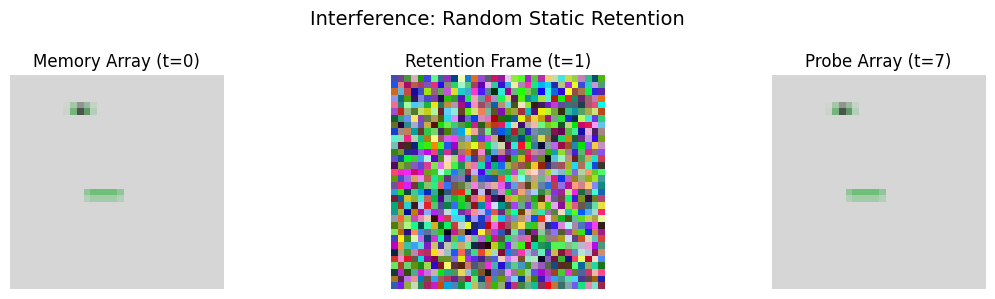

In [ ]:
# 4. Example of Static Retention Phase
sample_stim_noisy = replace_retention_with_static(sample_stim, sample_seq_len)
plot_trial_sequence(sample_stim_noisy, sample_seq_len, ri=sample_ri, trial_idx=0, title="Interference: Random Static Retention")

**Evaluate Static Noise**

In [ ]:
# 5. Testing with Static Noise
print("Evaluating Random Static Interference...")
df_static = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Random_Static",
    perturbation_fn=replace_retention_with_static,
    seed=42,
    save_outputs=True
)

print(f"Total static-noise trials: {len(df_static)}")
print(f"Overall static-noise CD accuracy: {df_static['correct'].mean():.4f}")

# Group and display the summary table
static_summary_df = (
    df_static
    .groupby(["variant", "set_size", "retention_interval"])
    .agg(
        accuracy=("correct", "mean"),
        n_trials=("correct", "count")
    )
    .reset_index()
    .sort_values(["variant", "retention_interval", "set_size"])
)
display(static_summary_df)

# Save to CSV
df_static.to_csv("lstm96_static_cd_trial_results.csv", index=False)
static_summary_df.to_csv("lstm96_static_cd_summary.csv", index=False)
print("Saved:")
print("lstm96_static_cd_trial_results.csv")
print("lstm96_static_cd_summary.csv")

Evaluating Random Static Interference...


Random_Static: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Total static-noise trials: 600
Overall static-noise CD accuracy: 0.6317


,variant,set_size,retention_interval,accuracy,n_trials
0,Color,2,0,1.000000,6
4,Color,4,0,1.000000,8
8,Color,6,0,1.000000,3
12,Color,8,0,1.000000,3
16,Color,10,0,1.000000,5
...,...,...,...,...,...
103,Size,4,18,0.333333,3
107,Size,6,18,0.285714,7
111,Size,8,18,0.571429,7
115,Size,10,18,0.000000,4


Saved:
lstm96_static_cd_trial_results.csv
lstm96_static_cd_summary.csv


**Graphs and Comparisons**

**Data Prep & Graph 1 (Overall Accuracy)**

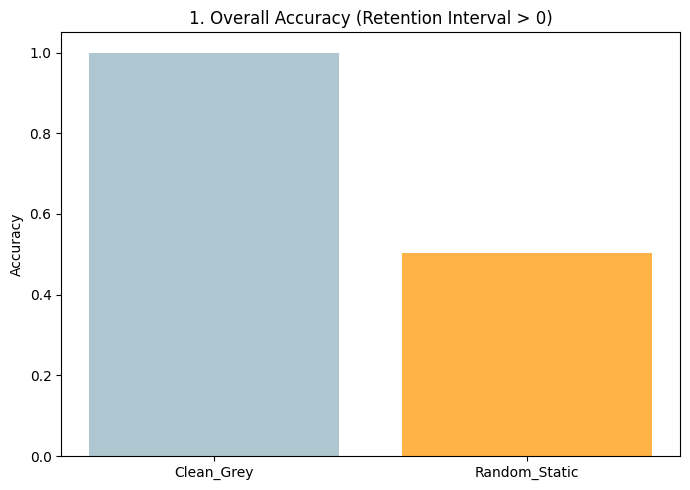

In [ ]:
# --- Combine Data for Plotting ---
clean_df = pd.read_csv("lstm96_clean_cd_trial_results.csv")
static_df = pd.read_csv("lstm96_static_cd_trial_results.csv")

df_all = pd.concat([clean_df, static_df], ignore_index=True)
# Filter out trials with 0 retention interval for fair comparison
df_plot = df_all[df_all["retention_interval"] > 0]

# --- Graph 1: Clean vs Static Accuracy ---
plt.figure(figsize=(7, 5))
summary_overall = df_plot.groupby("condition")["correct"].mean()
plt.bar(summary_overall.index, summary_overall.values, color=['#AEC6CF', '#FFB347'])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("1. Overall Accuracy (Retention Interval > 0)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_1_clean_vs_static.png", dpi=300)
plt.show()

**Graph 2 (By Retention Interval)**

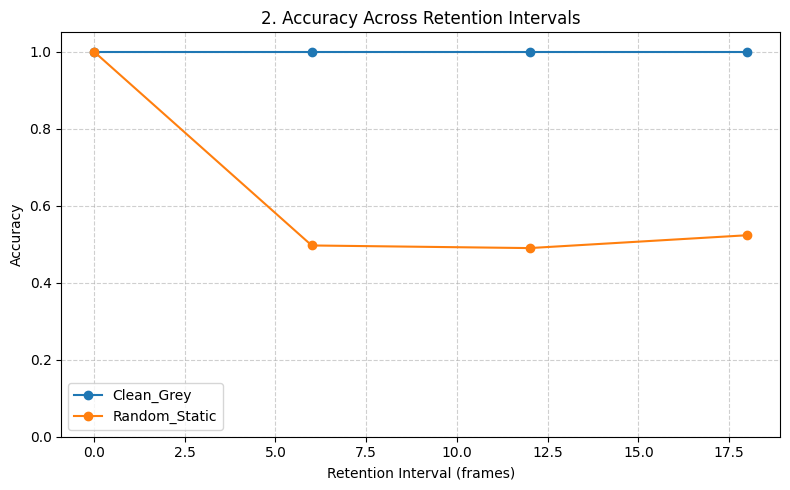

In [ ]:
# --- Graph 2: Accuracy by Retention Interval ---
plt.figure(figsize=(8, 5))
for condition in df_all["condition"].unique():
    # We use df_all here to include the 0 retention interval baseline
    temp = df_all[df_all["condition"] == condition].groupby("retention_interval")["correct"].mean()
    plt.plot(temp.index, temp.values, marker="o", label=condition)

plt.ylim(0, 1.05)
plt.xlabel("Retention Interval (frames)")
plt.ylabel("Accuracy")
plt.title("2. Accuracy Across Retention Intervals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("fig_2_accuracy_by_ri.png", dpi=300)
plt.show()

**Graph 3 (By CD Variant)**

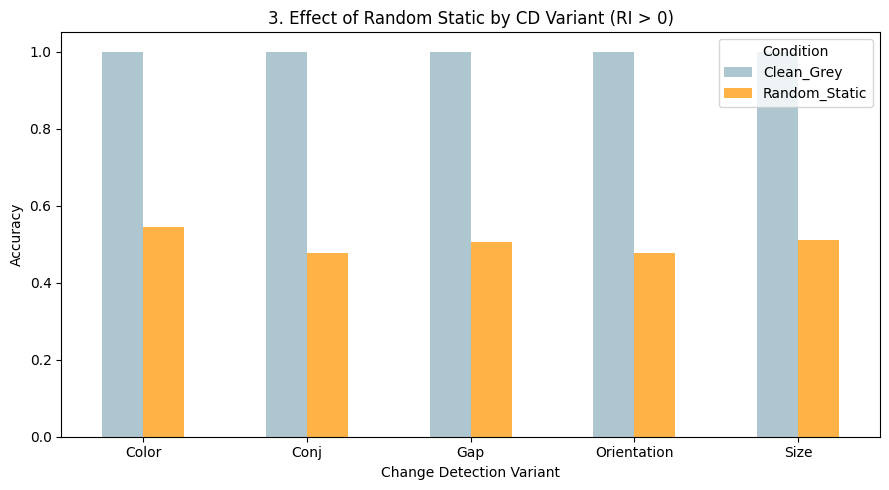

In [ ]:
# --- Graph 3: Accuracy by Change Detection Variant ---
summary_variant = df_plot.groupby(["variant", "condition"])["correct"].mean().unstack()

summary_variant.plot(kind="bar", figsize=(9, 5), color=['#AEC6CF', '#FFB347'])
plt.ylim(0, 1.05)
plt.xlabel("Change Detection Variant")
plt.ylabel("Accuracy")
plt.title("3. Effect of Random Static by CD Variant (RI > 0)")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.tight_layout()
plt.savefig("fig_3_accuracy_by_variant.png", dpi=300)
plt.show()

**Graph 4 (By Set Size)**

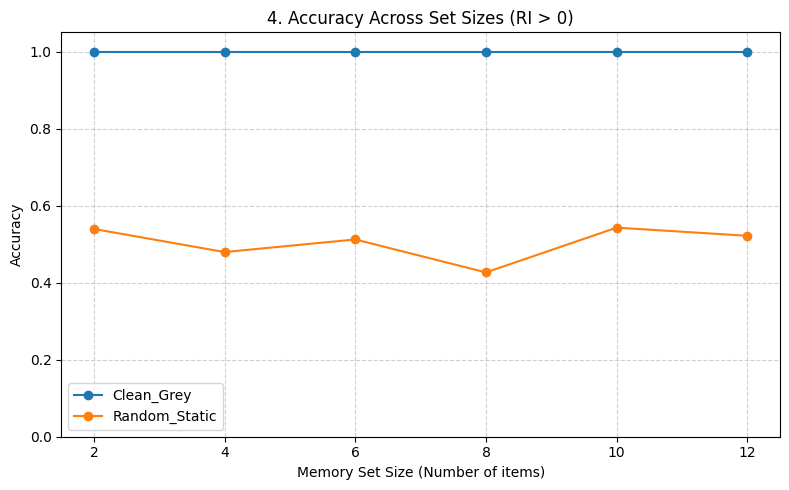

In [ ]:
# --- Graph 4: Accuracy by Set Size ---
plt.figure(figsize=(8, 5))
for condition in df_plot["condition"].unique():
    temp = df_plot[df_plot["condition"] == condition].groupby("set_size")["correct"].mean()
    plt.plot(temp.index, temp.values, marker="o", label=condition)

plt.ylim(0, 1.05)
plt.xlabel("Memory Set Size (Number of items)")
plt.ylabel("Accuracy")
plt.title("4. Accuracy Across Set Sizes (RI > 0)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("fig_4_accuracy_by_setsize.png", dpi=300)
plt.show()

# Stage 1

**Structured interference functions**

In [ ]:
# --- Stage 1: Structured Interference Functions ---

def replace_retention_with_checkerboard(
    stim_batch,
    seq_len,
    square_size=4,
    value_min=0.0,
    value_max=1.0
):
    """Replace retention frames with a checkerboard pattern."""
    noisy = stim_batch.clone()
    B, T, C, H, W = noisy.shape

    local_device = stim_batch.device
    dtype = stim_batch.dtype

    y_indices = torch.arange(H, device=local_device).view(-1, 1)
    x_indices = torch.arange(W, device=local_device).view(1, -1)

    board = ((y_indices // square_size) + (x_indices // square_size)) % 2
    board = board.to(dtype=dtype) * (value_max - value_min) + value_min
    board = board.unsqueeze(0).expand(C, H, W)

    for i in range(B):
        length = int(seq_len[i].item())
        retention_start = 1
        retention_end = length - 1

        if retention_end > retention_start:
            noisy[i, retention_start:retention_end] = board

    return noisy


def replace_retention_with_gratings(
    stim_batch,
    seq_len,
    stripe_width=4,
    orientation="vertical",
    value_min=0.0,
    value_max=1.0
):
    """Replace retention frames with vertical or horizontal grating stripes."""
    assert orientation in ["vertical", "horizontal"], "orientation must be 'vertical' or 'horizontal'"

    noisy = stim_batch.clone()
    B, T, C, H, W = noisy.shape

    local_device = stim_batch.device
    dtype = stim_batch.dtype

    if orientation == "vertical":
        indices = torch.arange(W, device=local_device).view(1, -1).expand(H, W)
    else:
        indices = torch.arange(H, device=local_device).view(-1, 1).expand(H, W)

    stripes = (indices // stripe_width) % 2
    stripes = stripes.to(dtype=dtype) * (value_max - value_min) + value_min
    stripes = stripes.unsqueeze(0).expand(C, H, W)

    for i in range(B):
        length = int(seq_len[i].item())
        retention_start = 1
        retention_end = length - 1

        if retention_end > retention_start:
            noisy[i, retention_start:retention_end] = stripes

    return noisy

**Visual sanity check**

Using trial index: 0
Retention interval: 6
Sequence length: 8


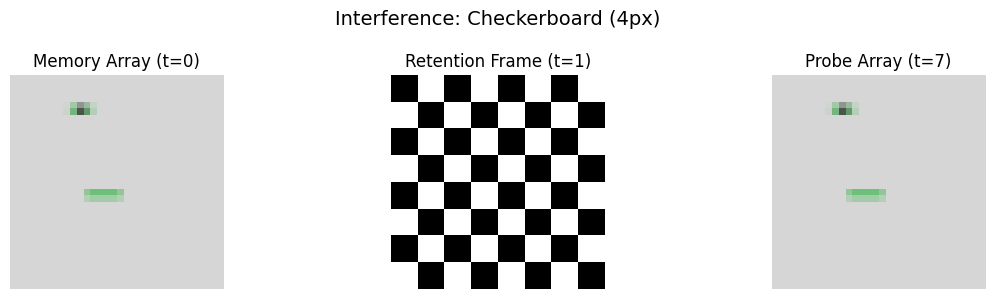

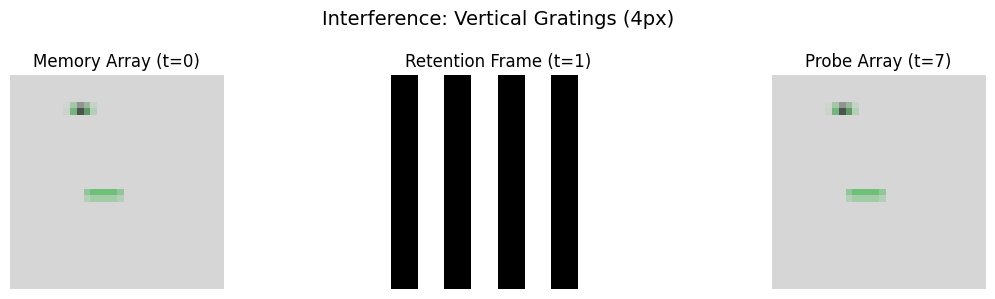

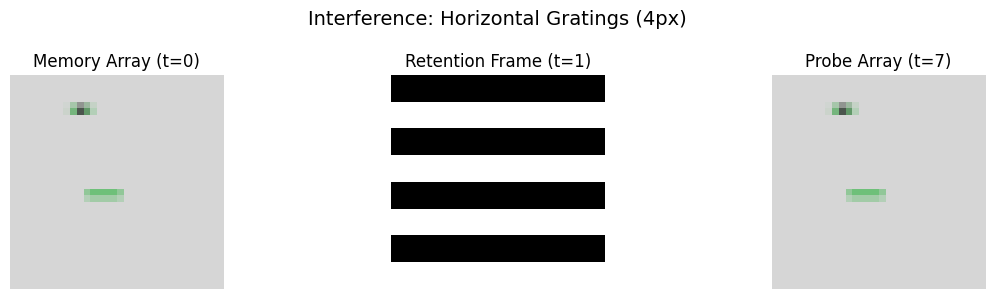

In [ ]:
# --- Visual Sanity Check for Stage 1 ---

sample_batch = next(iter(cd_loaders["CD_Color_Task"]))
sample_stim, resp_batch, sample_seq_len, sample_ri, sample_set_size = sample_batch

sample_stim = sample_stim.to(device)
sample_seq_len_dev = sample_seq_len.to(device)

# Pick a trial that actually has a retention phase
valid_trials = torch.where(sample_ri > 0)[0]

if len(valid_trials) == 0:
    raise ValueError("No trial with retention_interval > 0 found in this batch.")

trial_idx = int(valid_trials[0].item())

print("Using trial index:", trial_idx)
print("Retention interval:", int(sample_ri[trial_idx].item()))
print("Sequence length:", int(sample_seq_len[trial_idx].item()))

stim_check = replace_retention_with_checkerboard(
    sample_stim,
    sample_seq_len_dev,
    square_size=4
)

plot_trial_sequence(
    stim_check,
    sample_seq_len,
    ri=sample_ri,
    trial_idx=trial_idx,
    title="Interference: Checkerboard (4px)"
)

stim_grating_v = replace_retention_with_gratings(
    sample_stim,
    sample_seq_len_dev,
    stripe_width=4,
    orientation="vertical"
)

plot_trial_sequence(
    stim_grating_v,
    sample_seq_len,
    ri=sample_ri,
    trial_idx=trial_idx,
    title="Interference: Vertical Gratings (4px)"
)

stim_grating_h = replace_retention_with_gratings(
    sample_stim,
    sample_seq_len_dev,
    stripe_width=4,
    orientation="horizontal"
)

plot_trial_sequence(
    stim_grating_h,
    sample_seq_len,
    ri=sample_ri,
    trial_idx=trial_idx,
    title="Interference: Horizontal Gratings (4px)"
)

Re-evaluate clean and static with consistent names

In [ ]:
# --- Re-evaluate Stage 0 with consistent condition names ---

df_clean = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Clean_Grey",
    perturbation_fn=None,
    seed=42,
    save_outputs=True
)

df_static = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Random_Static",
    perturbation_fn=replace_retention_with_static,
    seed=42,
    save_outputs=True
)

df_clean.to_csv("lstm96_clean_cd_trial_results.csv", index=False)
df_static.to_csv("lstm96_static_cd_trial_results.csv", index=False)

print("Clean accuracy:", df_clean["correct"].mean())
print("Static accuracy:", df_static["correct"].mean())

Clean_Grey: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

...

Random_Static: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Random_Static: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean accuracy: 1.0
Static accuracy: 0.6316666666666667


**Evaluate structured interference**

In [ ]:
# --- Evaluate Structured Noise ---

print("\nEvaluating Checkerboard Interference...")
df_check = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Checkerboard",
    perturbation_fn=lambda batch, lengths: replace_retention_with_checkerboard(
        batch,
        lengths,
        square_size=4
    ),
    seed=42,
    save_outputs=True
)

df_check.to_csv("lstm96_checkerboard_cd_trial_results.csv", index=False)


print("\nEvaluating Vertical Gratings Interference...")
df_grating_v = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Grating_V",
    perturbation_fn=lambda batch, lengths: replace_retention_with_gratings(
        batch,
        lengths,
        stripe_width=4,
        orientation="vertical"
    ),
    seed=42,
    save_outputs=True
)

df_grating_v.to_csv("lstm96_grating_v_cd_trial_results.csv", index=False)


print("\nEvaluating Horizontal Gratings Interference...")
df_grating_h = evaluate_model(
    model=model,
    dataloaders=cd_loaders,
    condition_name="Grating_H",
    perturbation_fn=lambda batch, lengths: replace_retention_with_gratings(
        batch,
        lengths,
        stripe_width=4,
        orientation="horizontal"
    ),
    seed=42,
    save_outputs=True
)

df_grating_h.to_csv("lstm96_grating_h_cd_trial_results.csv", index=False)


for df, name in zip(
    [df_clean, df_static, df_check, df_grating_v, df_grating_h],
    ["Clean", "Static", "Checkerboard", "Grating_V", "Grating_H"]
):
    acc_all = df["correct"].mean()
    acc_ri = df[df["retention_interval"] > 0]["correct"].mean()

    print(f"{name} accuracy, all trials: {acc_all:.4f}")
    print(f"{name} accuracy, RI > 0:    {acc_ri:.4f}")


Evaluating Checkerboard Interference...


Checkerboard: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Checkerboard: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Checkerboard: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Checkerboard: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

...

Grating_H: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Grating_H: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Grating_H: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Grating_H: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean accuracy, all trials: 1.0000
Clean accuracy, RI > 0:    1.0000
Static accuracy, all trials: 0.6317
Static accuracy, RI > 0:    0.5034
Checkerboard accuracy, all trials: 0.6350
Checkerboard accuracy, RI > 0:    0.5079
Grating_V accuracy, all trials: 0.6483
Grating_V accuracy, RI > 0:    0.5258
Grating_H accuracy, all trials: 0.6300
Grating_H accuracy, RI > 0:    0.5011


**Grand comparison graphs**

In [ ]:
# --- The Grand Comparison Graphs ---

clean_df = pd.read_csv("lstm96_clean_cd_trial_results.csv")
static_df = pd.read_csv("lstm96_static_cd_trial_results.csv")
check_df = pd.read_csv("lstm96_checkerboard_cd_trial_results.csv")
grating_v_df = pd.read_csv("lstm96_grating_v_cd_trial_results.csv")
grating_h_df = pd.read_csv("lstm96_grating_h_cd_trial_results.csv")

df_all = pd.concat(
    [clean_df, static_df, check_df, grating_v_df, grating_h_df],
    ignore_index=True
)

# Safety mapping in case older CSVs used older condition names
condition_map = {
    "clean_grey_retention": "Clean_Grey",
    "Clean grey retention": "Clean_Grey",
    "random_static_retention": "Random_Static",
    "Random static retention": "Random_Static",
    "static_retention": "Random_Static"
}

df_all["condition"] = df_all["condition"].replace(condition_map)

print("Conditions found:", df_all["condition"].unique())

# Remove trials with no retention phase
df_plot = df_all[df_all["retention_interval"] > 0].copy()

order = ["Clean_Grey", "Random_Static", "Checkerboard", "Grating_V", "Grating_H"]
missing = [c for c in order if c not in df_plot["condition"].unique()]

if missing:
    raise ValueError(f"Missing conditions in df_plot: {missing}")

colors = ["#AEC6CF", "#FFB347", "#77DD77", "#CFCFC4", "#F49AC2"]

Conditions found: ['Clean_Grey' 'Random_Static' 'Checkerboard' 'Grating_V' 'Grating_H']


**Graph 1: Overall accuracy**

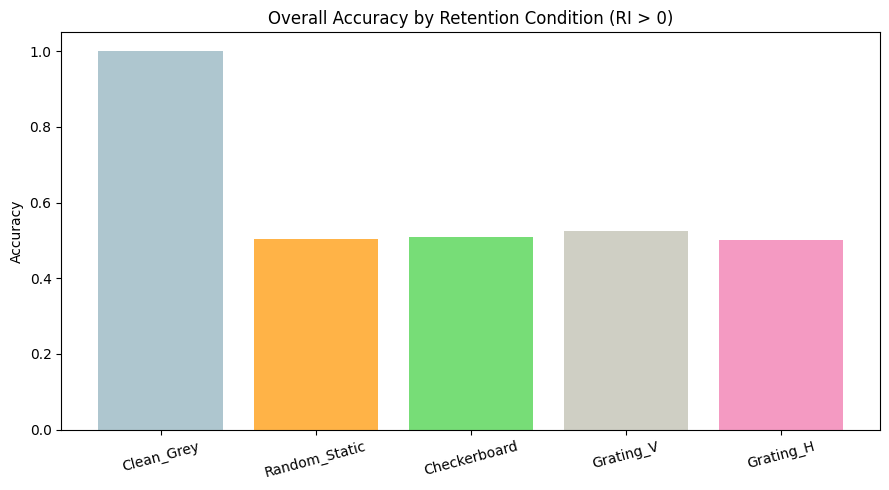

,condition,accuracy
0,Clean_Grey,1.000000
1,Random_Static,0.503371
2,Checkerboard,0.507865
3,Grating_V,0.525843
4,Grating_H,0.501124


In [ ]:
# --- Graph 1: Overall Accuracy Comparison ---

summary_overall = (
    df_plot
    .groupby("condition")["correct"]
    .mean()
    .loc[order]
)

plt.figure(figsize=(9, 5))
plt.bar(summary_overall.index, summary_overall.values, color=colors)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy by Retention Condition (RI > 0)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig_stage1_overall.png", dpi=300)
plt.show()

display(summary_overall.reset_index(name="accuracy"))

**Graph 2: Accuracy by CD variant**

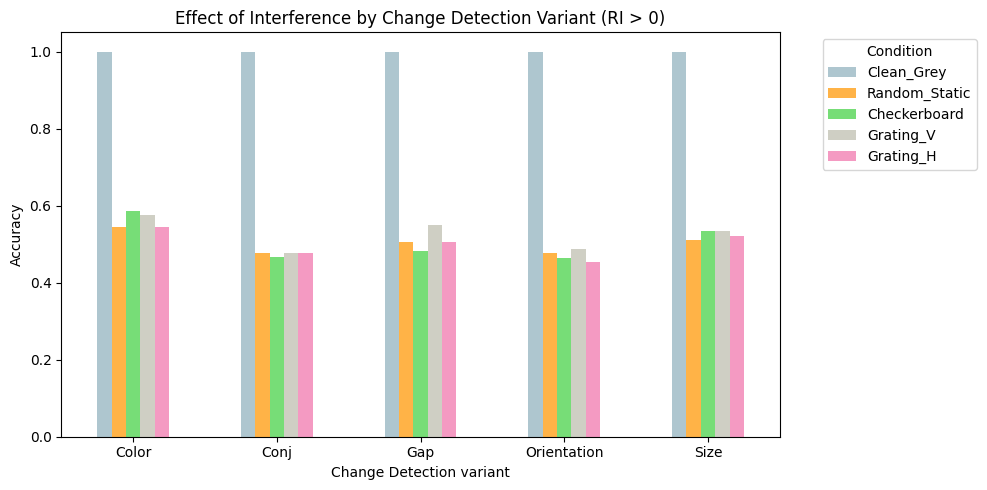

condition,Clean_Grey,Random_Static,Checkerboard,Grating_V,Grating_H
variant,,,,,
Color,1.0,0.543478,0.586957,0.576087,0.543478
Conj,1.0,0.477273,0.465909,0.477273,0.477273
Gap,1.0,0.505618,0.483146,0.550562,0.505618
Orientation,1.0,0.476744,0.465116,0.488372,0.453488
Size,1.0,0.511111,0.533333,0.533333,0.522222


In [ ]:
# --- Graph 2: Accuracy by CD Variant ---

summary_variant = (
    df_plot
    .groupby(["variant", "condition"])["correct"]
    .mean()
    .unstack()
)

summary_variant = summary_variant[order]

summary_variant.plot(kind="bar", figsize=(10, 5), color=colors)
plt.ylim(0, 1.05)
plt.xlabel("Change Detection variant")
plt.ylabel("Accuracy")
plt.title("Effect of Interference by Change Detection Variant (RI > 0)")
plt.xticks(rotation=0)
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig_stage1_variant.png", dpi=300)
plt.show()

display(summary_variant)

**Graph 3: Decision bias check**

,pred_change_rate,target_change_rate,accuracy,prediction_bias
condition,,,,
Clean_Grey,0.505618,0.505618,1.000000,0.000000
Random_Static,0.970787,0.505618,0.503371,0.465169
Checkerboard,0.970787,0.505618,0.507865,0.465169
Grating_V,0.930337,0.505618,0.525843,0.424719
Grating_H,0.959551,0.505618,0.501124,0.453933


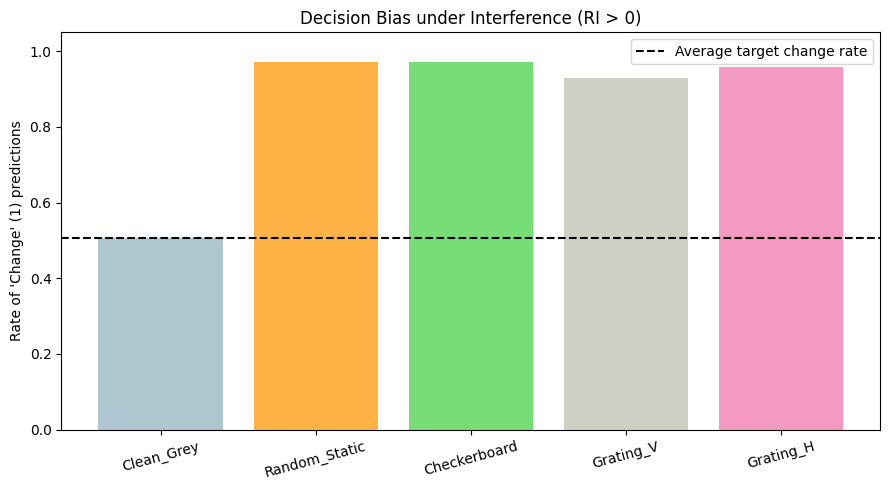

In [ ]:
# --- Graph 3: Bias Check ---

bias_summary = (
    df_plot
    .groupby("condition")
    .agg(
        pred_change_rate=("pred", "mean"),
        target_change_rate=("target", "mean"),
        accuracy=("correct", "mean")
    )
    .loc[order]
)

bias_summary["prediction_bias"] = (
    bias_summary["pred_change_rate"] - bias_summary["target_change_rate"]
)

display(bias_summary)

plt.figure(figsize=(9, 5))
plt.bar(bias_summary.index, bias_summary["pred_change_rate"], color=colors)
plt.axhline(
    bias_summary["target_change_rate"].mean(),
    color="black",
    linestyle="--",
    label="Average target change rate"
)
plt.ylim(0, 1.05)
plt.ylabel("Rate of 'Change' (1) predictions")
plt.title("Decision Bias under Interference (RI > 0)")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig("fig_stage1_bias.png", dpi=300)
plt.show()

# Stage 2

**1. Setup, folders, config, dependency check**

In [ ]:
# === Stage 2/3 — S2-0: setup, folders, config ===
import os, math, random, hashlib, shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

# --- depends only on the main setup/model cell ---
for _name in ["model", "device", "cd_loaders"]:
    assert _name in globals(), f"Missing '{_name}'. Run the main setup/model-loading cell first."

GLOBAL_SEED = 42
BATCH_SIZE_EVAL = 64

def reset_global_seed(seed=GLOBAL_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_global_seed()

# --- paper-ready output tree ---
PAPER_ROOT = "paper_outputs"
S2_IMG = os.path.join(PAPER_ROOT, "stage2", "sample_images")
S2_RES = os.path.join(PAPER_ROOT, "stage2", "results")
S2_PLT = os.path.join(PAPER_ROOT, "stage2", "plots")
S3_IMG = os.path.join(PAPER_ROOT, "stage3", "sample_images")
S3_RES = os.path.join(PAPER_ROOT, "stage3", "results")
S3_PLT = os.path.join(PAPER_ROOT, "stage3", "plots")
for _d in [S2_IMG, S2_RES, S2_PLT, S3_IMG, S3_RES, S3_PLT]:
    os.makedirs(_d, exist_ok=True)

# --- config (your confirmed choices) ---
HUE_ROTATION_DEG = 60.0          # objects: +60 deg hue rotation (grey background stays grey)
BG_RECOLOR = (0.45, 0.55, 0.85)  # background-recolour condition: steel-blue
DPI = 300

print("Output tree ready under:", PAPER_ROOT)
print(f"Objects: +{HUE_ROTATION_DEG:.0f} deg hue rotation | Background recolour RGB: {BG_RECOLOR}")

Output tree ready under: paper_outputs
Objects: +60 deg hue rotation | Background recolour RGB: (0.45, 0.55, 0.85)


**Stage 2 — Cell S2-1: Shared foundation (fixed RI>0 trials + helpers + evaluator)**

In [ ]:
# === S2-1: rebuild fixed trials + apply_to_memory_and_probe + evaluator (used by Stage 2 AND Stage 3) ===
TASK_TO_VARIANT = {
    "CD_Color_Task": "Color", "CD_Orientation_Task": "Orientation",
    "CD_Size_Task": "Size", "CD_Gap_Task": "Gap", "CD_Conj_Task": "Conjunction",
}

def _rows(t, idx):
    return t.index_select(0, idx.to(t.device)).detach().cpu()

def _checksum(t):
    return hashlib.md5(t.detach().cpu().contiguous().numpy().tobytes()).hexdigest()

def collect_fixed_ri_trials(cd_loaders):
    fixed = {}
    for task_name, loader in cd_loaders.items():
        variant = TASK_TO_VARIANT.get(task_name, task_name)
        S=[];R=[];L=[];I=[];Z=[]
        for batch in loader:
            stim, resp, seq_len, ri, set_size = batch[:5]   # CD_Conj returns extra fields
            idx = torch.where(ri.detach().cpu() > 0)[0]
            if len(idx) == 0:
                continue
            S.append(_rows(stim, idx)); R.append(_rows(resp, idx)); L.append(_rows(seq_len, idx))
            I.append(_rows(ri, idx));  Z.append(_rows(set_size, idx))
        fixed[variant] = {"task_name": task_name, "variant": variant,
                          "stim": torch.cat(S), "resp": torch.cat(R),
                          "seq_len": torch.cat(L), "ri": torch.cat(I), "set_size": torch.cat(Z)}
        assert torch.all(fixed[variant]["ri"] > 0)
    return fixed

reset_global_seed()
fixed_clean_trials = collect_fixed_ri_trials(cd_loaders)

# reproducibility fingerprints (compare to old Stage 2 to confirm identical trial set)
_fp = []
for v, d in fixed_clean_trials.items():
    _fp.append({"task": d["task_name"], "variant": v, "n_trials": int(d["stim"].shape[0]),
                "stim_checksum": _checksum(d["stim"]), "resp_checksum": _checksum(d["resp"]),
                "seq_len_checksum": _checksum(d["seq_len"]), "ri_checksum": _checksum(d["ri"]),
                "set_size_checksum": _checksum(d["set_size"])})
fingerprint_df = pd.DataFrame(_fp)
fingerprint_df.to_csv(os.path.join(S2_RES, "trial_fingerprints.csv"), index=False)
display(fingerprint_df)
print("Total fixed RI>0 trials:", int(sum(d["stim"].shape[0] for d in fixed_clean_trials.values())))

def apply_to_memory_and_probe(stim, seq_len, frame_transform):
    """Apply frame_transform ONLY to Memory (t=0) and Probe (t=seq_len-1); retention frames untouched."""
    out = stim.clone()
    bidx = torch.arange(out.shape[0], device=out.device)
    probe = seq_len.to(out.device).long() - 1
    out[:, 0] = frame_transform(out[:, 0])
    out[bidx, probe] = frame_transform(out[bidx, probe])
    return out

def evaluate_condition_on_fixed_trials(model, fixed_clean_trials, condition_name, transform_fn,
                                       batch_size=BATCH_SIZE_EVAL, seed=GLOBAL_SEED):
    reset_global_seed(seed); model.eval()
    recs = []
    with torch.no_grad():
        for variant, d in fixed_clean_trials.items():
            task_name = d["task_name"]; n = d["stim"].shape[0]
            for s in tqdm(range(0, n, batch_size), desc=f"{condition_name}: {task_name}", leave=False):
                e = min(s + batch_size, n)
                stim = d["stim"][s:e].to(device)
                resp = d["resp"][s:e].to(device)
                seq_len_cpu = d["seq_len"][s:e].cpu().long()
                seq_len_dev = seq_len_cpu.to(device)
                ri = d["ri"][s:e]; ss = d["set_size"][s:e]
                stim_eval = transform_fn(stim, seq_len_cpu)
                final_t = seq_len_dev - 1
                bidx = torch.arange(stim_eval.size(0), device=device)
                out, _, _, _, _ = model(stim_eval, task_name, seq_len_cpu)   # notebook forward signature
                pred = torch.round(torch.sigmoid(out)).squeeze(-1)
                fp_ = pred[bidx, final_t].long(); ft = resp[bidx, final_t].long()
                corr = (fp_ == ft).long().cpu(); fp_c = fp_.cpu(); ft_c = ft.cpu()
                for i in range(e - s):
                    recs.append({"task": task_name, "variant": variant, "trial_index": int(s + i),
                                 "set_size": int(ss[i].item()), "retention_interval": int(ri[i].item()),
                                 "seq_len": int(seq_len_cpu[i].item()), "condition": condition_name,
                                 "correct": int(corr[i].item()), "prediction": int(fp_c[i].item()),
                                 "pred": int(fp_c[i].item()), "target": int(ft_c[i].item())})
    df = pd.DataFrame(recs)
    print(f"{condition_name}: acc={df['correct'].mean():.4f} | changed_rate={df['prediction'].mean():.4f} | n={len(df)}")
    return df

print("Foundation ready: fixed_clean_trials, apply_to_memory_and_probe, evaluate_condition_on_fixed_trials")

,task,variant,n_trials,stim_checksum,resp_checksum,seq_len_checksum,ri_checksum,set_size_checksum
0,CD_Color_Task,Color,92,523387f35a1d5ff31206ede230bdb9f3,f0024dfd9f5ca9e86a5a1af852b8a728,81912dfa11ba990b9456c1155ba33254,c8411a2a006ebd35ad6e896c83908765,cb8535f4a40a4164957a1d5ac13222c1
1,CD_Orientation_Task,Orientation,86,86fecc4f82479c22c403ae1bb67c8258,99e62aa5a6ba124ddffa217519a13561,1ca5814c1563cfa728a2a07aff2aeaaa,d532b6eb520fa403ee9c2d59dfbe48da,fa1d99881bf6a5a11cb3238820867ebc
2,CD_Size_Task,Size,90,a1508db2107370ebe27ebedc8a0d2919,14b2b2ff6cc6d447463be15be916a94b,4da21c0c9678dbcc422a946a6661b073,2063ef990018a1c7ead1e8398f7310cd,5ae4b46be51df300ff03f44fbb828f6f
3,CD_Gap_Task,Gap,89,8450807a4ee538f7a19c9fdac4c25ffa,246193b7e5517e8941c1710cae835b62,d246401f407a544d13314b72abfc6702,013e7744a7ad0841f25002e734aadd31,c0931997c092667c75c4f5d01ff61c8c
4,CD_Conj_Task,Conjunction,88,0adfc4be41b1040fb1b4c46ff476f8c8,c3cbe803139b6a39ec4f9e7fc59d2e6a,c98e7f16b57fcc0b1bdcb2851a25cc5e,cabe568e59451ddf3ef9bddf62b56e3a,5371f99d951786e78c44d412530a031f


Total fixed RI>0 trials: 445
Foundation ready: fixed_clean_trials, apply_to_memory_and_probe, evaluate_condition_on_fixed_trials


**Stage 2 — Cell S2-2: Background & colour probe (measure, don't assume)**

In [ ]:
# === S2-2: measure the real background value + chroma threshold from the data ===
reset_global_seed()
_sample = fixed_clean_trials["Color"]["stim"][:64]   # [n, T, C, H, W]
_mem = _sample[:, 0]                                  # memory frames [n, C, H, W]
_chroma = (_mem.max(1).values - _mem.min(1).values)  # per-pixel chroma [n, H, W]
_lum = _mem.mean(1)
_bg_mask = _chroma < 0.05
_obj = _chroma[_chroma > 0.15]

BG_VALUE = float(_lum[_bg_mask].median()) if _bg_mask.any() else 0.84
CHROMA_TAU = 0.12   # objects (chromatic) vs background (achromatic) separator

print(f"Estimated background grey value : {BG_VALUE:.3f}")
print(f"Background chroma (mean)        : {float(_chroma[_bg_mask].mean()):.3f}")
print(f"Object chroma (median)          : {float(_obj.median()):.3f}")
print(f"CHROMA_TAU                       : {CHROMA_TAU}")
pd.DataFrame([{"bg_value": BG_VALUE, "chroma_tau": CHROMA_TAU,
               "bg_chroma_mean": float(_chroma[_bg_mask].mean()),
               "obj_chroma_median": float(_obj.median())}]
            ).to_csv(os.path.join(S2_RES, "pixel_stats.csv"), index=False)

Estimated background grey value : 0.839
Background chroma (mean)        : 0.000
Object chroma (median)          : 0.282
CHROMA_TAU                       : 0.12


**Cell S2-3: Define transforms (hue rotation + background recolour) + condition dict**

In [ ]:
# === S2-3: object recolour (+60 deg hue rotation) and background recolour; build condition dict ===
def _hue_rotation_matrix(deg):
    a = math.cos(math.radians(deg)); b = math.sin(math.radians(deg))
    lr, lg, lb = 0.213, 0.715, 0.072  # SVG feColorMatrix hueRotate (luminance-preserving; grey stays grey)
    return torch.tensor([
        [lr + a*(1-lr) + b*(-lr),      lg + a*(-lg)   + b*(-lg),     lb + a*(-lb)   + b*(1-lb)],
        [lr + a*(-lr) + b*(0.143),     lg + a*(1-lg)  + b*(0.140),   lb + a*(-lb)   + b*(-0.283)],
        [lr + a*(-lr) + b*(-(1-lr)),   lg + a*(-lg)   + b*(lg),      lb + a*(1-lb)  + b*(lb)],
    ], dtype=torch.float32)

HUE_M = _hue_rotation_matrix(HUE_ROTATION_DEG)

def object_recolor_frame(frames):
    # frames [B,C,H,W] in [0,1]; rotate object hue, achromatic background unchanged by construction
    M = HUE_M.to(frames.device, frames.dtype)
    return torch.einsum('ij,bjhw->bihw', M, frames).clamp(0, 1)

def background_recolor_frame(frames):
    chroma = frames.max(1, keepdim=True).values - frames.min(1, keepdim=True).values  # [B,1,H,W]
    bg_mask = (chroma < CHROMA_TAU).float()
    bg = torch.tensor(BG_RECOLOR, dtype=frames.dtype, device=frames.device).view(1, 3, 1, 1)
    return (frames * (1 - bg_mask) + bg * bg_mask).clamp(0, 1)

def identity_transform(stim, seq_len):   return stim.clone()
def t_object(stim, seq_len):             return apply_to_memory_and_probe(stim, seq_len, object_recolor_frame)
def t_background(stim, seq_len):         return apply_to_memory_and_probe(stim, seq_len, background_recolor_frame)

STAGE2_CONDITIONS = {
    "Clean_Grey": identity_transform,
    "OOD_Object_Recolor": t_object,
    "OOD_Background_Recolor": t_background,
}
print("Stage 2 conditions:", list(STAGE2_CONDITIONS))

Stage 2 conditions: ['Clean_Grey', 'OOD_Object_Recolor', 'OOD_Background_Recolor']


**Stage 2 — Cell S2-4: Label-preservation check + save & display sample stimulus images**

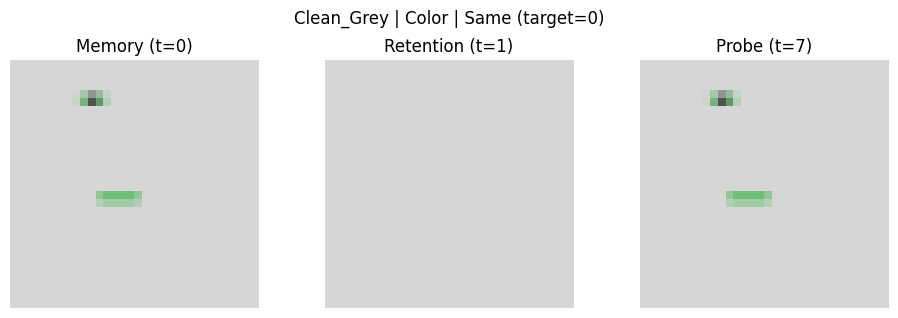

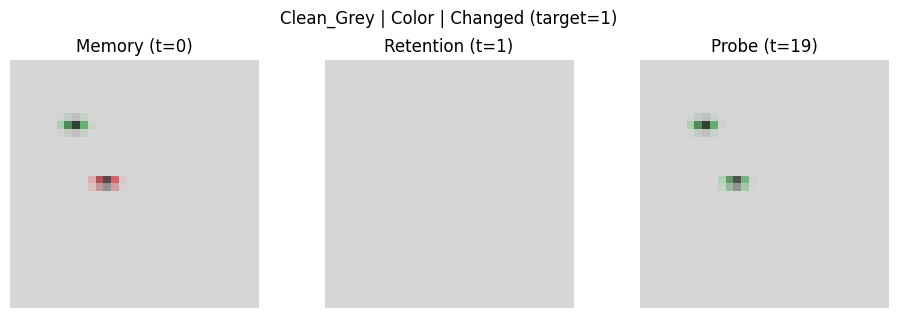

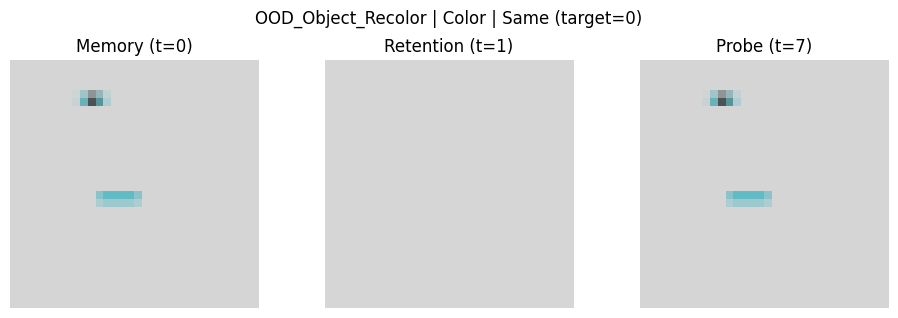

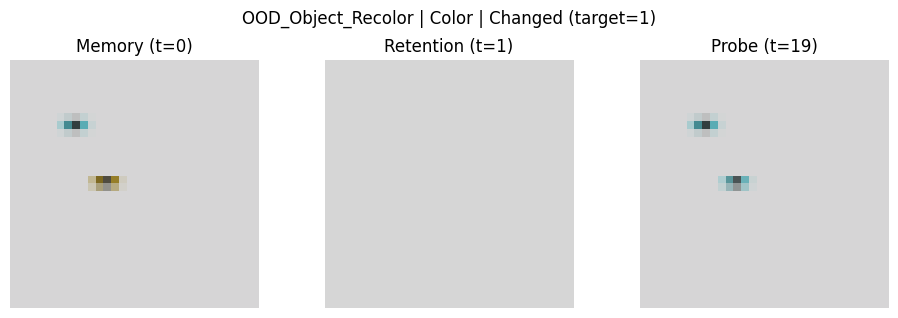

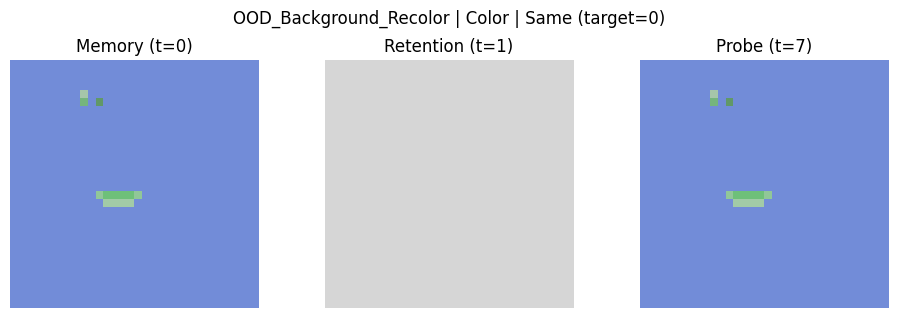

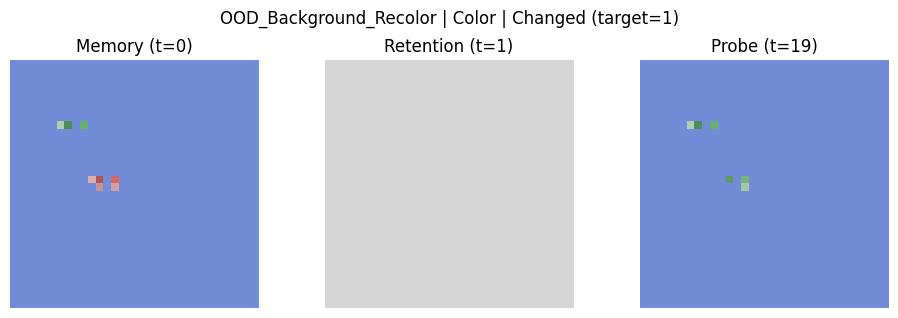

,condition,trial,target,clean_mem_eq_probe,transformed_mem_eq_probe,relationship_preserved,retention_unchanged
0,Clean_Grey,Same,0,True,True,True,True
1,Clean_Grey,Changed,1,False,False,True,True
2,OOD_Object_Recolor,Same,0,True,True,True,True
3,OOD_Object_Recolor,Changed,1,False,False,True,True
4,OOD_Background_Recolor,Same,0,True,True,True,True
5,OOD_Background_Recolor,Changed,1,False,False,True,True


LABEL-PRESERVATION CHECK: PASS


In [ ]:
# === S2-4: verify cleanliness, then render+save Memory/Retention/Probe for each condition ===
reset_global_seed()
color = fixed_clean_trials["Color"]

def _target_of(d, i):
    L = int(d["seq_len"][i].item()); return int(d["resp"][i, L - 1].item())

same_i = changed_i = None
for i in range(color["stim"].shape[0]):
    t = _target_of(color, i)
    if t == 0 and same_i is None: same_i = i
    if t == 1 and changed_i is None: changed_i = i
    if same_i is not None and changed_i is not None: break
assert same_i is not None and changed_i is not None, "Could not find both Same and Changed Color trials."

def show_save_sequence(stim_seq, L, title, path):
    ret_t = 1 if L > 2 else None
    frames = [0] + ([ret_t] if ret_t else []) + [L - 1]
    labels = ["Memory (t=0)"] + ([f"Retention (t={ret_t})"] if ret_t else []) + [f"Probe (t={L-1})"]
    fig, axes = plt.subplots(1, len(frames), figsize=(3.2 * len(frames), 3.2))
    if len(frames) == 1: axes = [axes]
    fig.suptitle(title, fontsize=12)
    for ax, t, lab in zip(axes, frames, labels):
        ax.imshow(stim_seq[t].permute(1, 2, 0).clamp(0, 1).cpu().numpy()); ax.set_title(lab); ax.axis("off")
    plt.tight_layout()
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.show(); plt.close(fig)

checks = []
for cond, fn in STAGE2_CONDITIONS.items():
    for label, idx in [("Same", same_i), ("Changed", changed_i)]:
        stim1 = color["stim"][idx:idx+1].to(device)
        sl1 = color["seq_len"][idx:idx+1]; L = int(sl1.item())
        tr = fn(stim1, sl1)[0].cpu()
        clean_eq = bool(torch.allclose(stim1[0, 0].cpu(), stim1[0, L-1].cpu(), atol=1e-6))
        trans_eq = bool(torch.allclose(tr[0], tr[L-1], atol=1e-6))
        ret_unchanged = bool(torch.allclose(stim1[0, 1].cpu(), tr[1], atol=1e-6)) if L > 2 else True
        checks.append({"condition": cond, "trial": label, "target": (0 if label == "Same" else 1),
                       "clean_mem_eq_probe": clean_eq, "transformed_mem_eq_probe": trans_eq,
                       "relationship_preserved": (clean_eq == trans_eq), "retention_unchanged": ret_unchanged})
        show_save_sequence(tr, L, f"{cond} | Color | {label} (target={0 if label=='Same' else 1})",
                           os.path.join(S2_IMG, f"{cond}_Color_{label}.png"))

chk = pd.DataFrame(checks); display(chk)
chk.to_csv(os.path.join(S2_RES, "label_preservation_check.csv"), index=False)
ok = bool(chk["relationship_preserved"].all() and chk["retention_unchanged"].all())
print("LABEL-PRESERVATION CHECK:", "PASS" if ok else "FAIL — inspect before trusting results")

**Stage 2 — Cell S2-5: Run evaluation + save raw trial-level predictions**

In [ ]:
# === S2-5: evaluate all Stage 2 conditions; save raw per-trial CSVs ===
reset_global_seed()
stage2_raw = {}
for cond, fn in STAGE2_CONDITIONS.items():
    df = evaluate_condition_on_fixed_trials(model, fixed_clean_trials, cond, fn)
    stage2_raw[cond] = df
    df.to_csv(os.path.join(S2_RES, f"raw_{cond}.csv"), index=False)

df_stage2_all = pd.concat(stage2_raw.values(), ignore_index=True)
df_stage2_all.to_csv(os.path.join(S2_RES, "raw_all_conditions.csv"), index=False)
print("Saved raw Stage 2 predictions to:", S2_RES)
display(df_stage2_all.head())

Clean_Grey: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

Clean_Grey: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

...

OOD_Background_Recolor: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

OOD_Background_Recolor: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

OOD_Background_Recolor: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

OOD_Background_Recolor: acc=0.5034 | changed_rate=0.9978 | n=445
Saved raw Stage 2 predictions to: paper_outputs/stage2/results


,task,variant,trial_index,set_size,retention_interval,seq_len,condition,correct,prediction,pred,target
0,CD_Color_Task,Color,0,2,6,8,Clean_Grey,1,0,0,0
1,CD_Color_Task,Color,1,2,18,20,Clean_Grey,1,1,1,1
2,CD_Color_Task,Color,2,2,18,20,Clean_Grey,1,0,0,0
3,CD_Color_Task,Color,3,2,18,20,Clean_Grey,1,0,0,0
4,CD_Color_Task,Color,4,2,6,8,Clean_Grey,1,1,1,1


**Stage 2 — Cell S2-6: Summaries (condition / variant / macro) + save CSVs**

In [ ]:
# === S2-6: condition, per-variant, and macro-average summaries ===
def _summarize(df, group):
    return (df.groupby(group)
              .agg(accuracy=("correct", "mean"),
                   predicted_changed_rate=("prediction", "mean"),
                   n_trials=("correct", "size"))
              .reset_index())

cond_order = ["Clean_Grey", "OOD_Object_Recolor", "OOD_Background_Recolor"]

summary_by_variant = _summarize(df_stage2_all, ["variant", "condition"])
summary_condition_weighted = _summarize(df_stage2_all, ["condition"])
summary_macro = (summary_by_variant.groupby("condition")
                 .agg(accuracy=("accuracy", "mean"),
                      predicted_changed_rate=("predicted_changed_rate", "mean"),
                      n_variants=("variant", "nunique")).reset_index())

for _df in (summary_condition_weighted, summary_macro):
    _df["condition"] = pd.Categorical(_df["condition"], cond_order)
    _df.sort_values("condition", inplace=True)

summary_by_variant.to_csv(os.path.join(S2_RES, "summary_by_variant.csv"), index=False)
summary_condition_weighted.to_csv(os.path.join(S2_RES, "summary_condition.csv"), index=False)
summary_macro.to_csv(os.path.join(S2_RES, "summary_macro.csv"), index=False)

print("Macro-averaged Stage 2 summary:"); display(summary_macro)
print("Per-variant Stage 2 summary:");   display(summary_by_variant)

Macro-averaged Stage 2 summary:


,condition,accuracy,predicted_changed_rate,n_variants
0,Clean_Grey,1.000000,0.504865,5
2,OOD_Object_Recolor,0.936115,0.440980,5
1,OOD_Background_Recolor,0.502592,0.997727,5


Per-variant Stage 2 summary:


,variant,condition,accuracy,predicted_changed_rate,n_trials
0,Color,Clean_Grey,1.000000,0.554348,92
1,Color,OOD_Background_Recolor,0.554348,1.000000,92
2,Color,OOD_Object_Recolor,0.793478,0.347826,92
3,Conjunction,Clean_Grey,1.000000,0.465909,88
4,Conjunction,OOD_Background_Recolor,0.454545,0.988636,88
5,Conjunction,OOD_Object_Recolor,0.965909,0.431818,88
6,Gap,Clean_Grey,1.000000,0.505618,89
7,Gap,OOD_Background_Recolor,0.505618,1.000000,89
8,Gap,OOD_Object_Recolor,1.000000,0.505618,89
9,Orientation,Clean_Grey,1.000000,0.465116,86


**Stage 2 — Cell S2-7: Plots (300 dpi) + display**

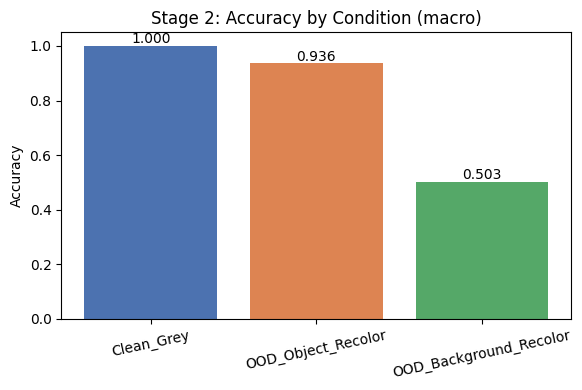

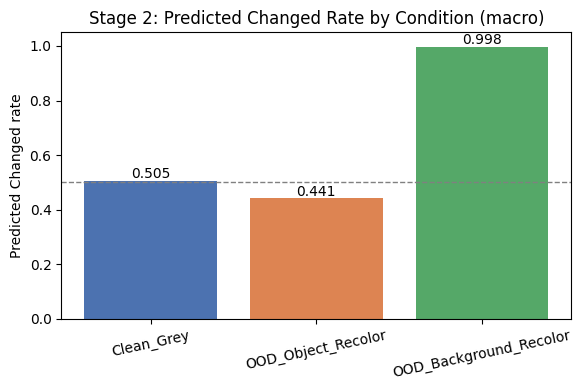

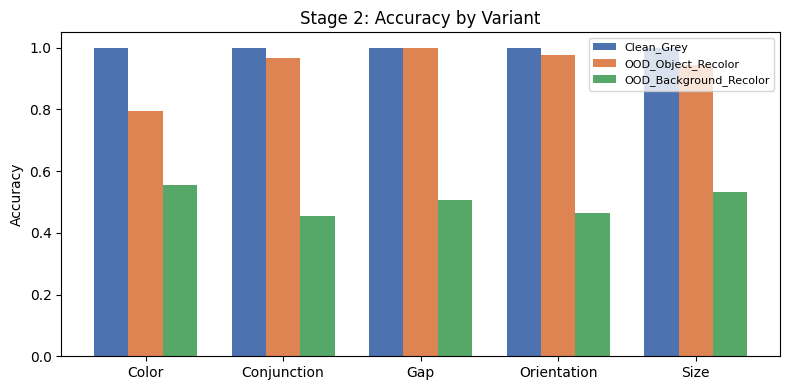

In [ ]:
# === S2-7: Stage 2 figures (saved as 300-dpi PNG and shown inline) ===
_mac = summary_macro.set_index("condition").loc[cond_order]
_colors = ["#4C72B0", "#DD8452", "#55A868"]

# Plot 1: accuracy by condition
fig = plt.figure(figsize=(6, 4))
plt.bar(cond_order, _mac["accuracy"].values, color=_colors)
for i, v in enumerate(_mac["accuracy"].values): plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylim(0, 1.05); plt.ylabel("Accuracy"); plt.title("Stage 2: Accuracy by Condition (macro)")
plt.xticks(rotation=12); plt.tight_layout()
fig.savefig(os.path.join(S2_PLT, "accuracy_by_condition.png"), dpi=DPI, bbox_inches="tight"); plt.show(); plt.close(fig)

# Plot 2: predicted-Changed rate by condition
fig = plt.figure(figsize=(6, 4))
plt.bar(cond_order, _mac["predicted_changed_rate"].values, color=_colors)
for i, v in enumerate(_mac["predicted_changed_rate"].values): plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.axhline(0.5, ls="--", c="grey", lw=1)
plt.ylim(0, 1.05); plt.ylabel("Predicted Changed rate"); plt.title("Stage 2: Predicted Changed Rate by Condition (macro)")
plt.xticks(rotation=12); plt.tight_layout()
fig.savefig(os.path.join(S2_PLT, "predicted_changed_by_condition.png"), dpi=DPI, bbox_inches="tight"); plt.show(); plt.close(fig)

# Plot 3: accuracy by variant x condition
_piv = summary_by_variant.pivot(index="variant", columns="condition", values="accuracy")[cond_order]
fig = plt.figure(figsize=(8, 4))
x = np.arange(len(_piv.index)); w = 0.25
for k, cond in enumerate(cond_order):
    plt.bar(x + (k - 1) * w, _piv[cond].values, width=w, label=cond, color=_colors[k])
plt.xticks(x, _piv.index); plt.ylim(0, 1.05); plt.ylabel("Accuracy")
plt.title("Stage 2: Accuracy by Variant"); plt.legend(fontsize=8); plt.tight_layout()
fig.savefig(os.path.join(S2_PLT, "accuracy_by_variant.png"), dpi=DPI, bbox_inches="tight"); plt.show(); plt.close(fig)

# Stage 3


**Stage 3 — Cell S3-0: Setup & contrast grid**

In [ ]:
# === S3-0: Stage 3 setup (reuses the S2-1 foundation) ===
assert "fixed_clean_trials" in globals() and "evaluate_condition_on_fixed_trials" in globals(), \
    "Run the Stage 2 foundation cell (S2-1) first."
ALPHAS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
print("Stage 3 distractor-contrast levels (alpha):", ALPHAS)

Stage 3 distractor-contrast levels (alpha): [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]


**Stage 3 — Cell S3-1: Contrast-scaled static distractor + save & display sample images**

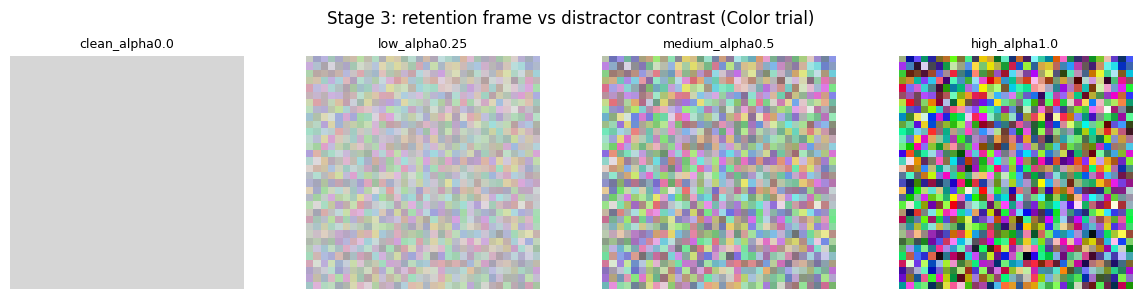

In [ ]:
# === S3-1: amplitude-scaled random-static retention distractor; sample images across alpha ===
def make_static_retention(alpha):
    def _fn(stim, seq_len):
        out = stim.clone()
        for i in range(out.shape[0]):
            L = int(seq_len[i].item())
            if L - 1 > 1:  # retention frames are t = 1 .. L-2
                sl = out[i, 1:L-1]
                noise = torch.empty_like(sl).uniform_(0, 1)
                out[i, 1:L-1] = (BG_VALUE + alpha * (noise - BG_VALUE)).clamp(0, 1)
        return out
    return _fn

reset_global_seed()
color = fixed_clean_trials["Color"]
idx = int(torch.where(color["seq_len"] > 2)[0][0].item())   # a delayed trial with real retention frames
stim1 = color["stim"][idx:idx+1].to(device); sl1 = color["seq_len"][idx:idx+1]

levels = [("clean_alpha0.0", 0.0), ("low_alpha0.25", 0.25), ("medium_alpha0.5", 0.5), ("high_alpha1.0", 1.0)]
fig, axes = plt.subplots(1, len(levels), figsize=(3.0 * len(levels), 3.0))
fig.suptitle("Stage 3: retention frame vs distractor contrast (Color trial)", fontsize=12)
for ax, (name, a) in zip(axes, levels):
    reset_global_seed()  # identical noise realisation across levels -> same pattern, scaled by alpha
    pert = make_static_retention(a)(stim1, sl1)[0]
    img = pert[1].permute(1, 2, 0).clamp(0, 1).cpu().numpy()
    ax.imshow(img); ax.set_title(name, fontsize=9); ax.axis("off")
    f2 = plt.figure(figsize=(3, 3)); plt.imshow(img); plt.axis("off"); plt.title(name, fontsize=9)
    f2.savefig(os.path.join(S3_IMG, f"retention_{name}.png"), dpi=DPI, bbox_inches="tight"); plt.close(f2)
plt.tight_layout()
fig.savefig(os.path.join(S3_IMG, "retention_contrast_strip.png"), dpi=DPI, bbox_inches="tight")
plt.show(); plt.close(fig)

**Stage 3 — Cell S3-2: Contrast sweep + save CSVs (raw / macro / per-variant)**

In [ ]:
# === S3-2: evaluate across the alpha grid; save raw + macro + per-variant summaries ===
reset_global_seed()
s3_raw, s3_macro = [], []
for a in ALPHAS:
    cond = f"static_alpha_{a:.2f}"
    df = evaluate_condition_on_fixed_trials(model, fixed_clean_trials, cond, make_static_retention(a))
    df["alpha"] = a
    s3_raw.append(df)
    pv = df.groupby("variant").agg(acc=("correct", "mean"), pcr=("prediction", "mean")).reset_index()
    s3_macro.append({"alpha": a,
                     "accuracy_macro": pv["acc"].mean(), "predicted_changed_macro": pv["pcr"].mean(),
                     "accuracy_weighted": df["correct"].mean(),
                     "predicted_changed_weighted": df["prediction"].mean(), "n_trials": len(df)})

s3_raw_df = pd.concat(s3_raw, ignore_index=True)
s3_raw_df.to_csv(os.path.join(S3_RES, "raw_all_alphas.csv"), index=False)
macro_alpha = pd.DataFrame(s3_macro)
macro_alpha.to_csv(os.path.join(S3_RES, "summary_macro_by_alpha.csv"), index=False)
by_var_alpha = (s3_raw_df.groupby(["variant", "alpha"])
                .agg(accuracy=("correct", "mean"), predicted_changed_rate=("prediction", "mean"),
                     n_trials=("correct", "size")).reset_index())
by_var_alpha.to_csv(os.path.join(S3_RES, "summary_by_variant_alpha.csv"), index=False)

print("Macro dose-response:"); display(macro_alpha)
print(f"Anchor check -> alpha=0 acc={macro_alpha.iloc[0]['accuracy_macro']:.3f} (expect ~1.0)"
      f" | alpha=1 acc={macro_alpha.iloc[-1]['accuracy_macro']:.3f} (expect ~0.50, matches Stage 1 static)")

static_alpha_0.00: CD_Color_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_0.00: CD_Orientation_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_0.00: CD_Size_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_0.00: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_0.00: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

...

static_alpha_1.00: CD_Gap_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_1.00: CD_Conj_Task:   0%|          | 0/2 [00:00<?, ?it/s]

static_alpha_1.00: acc=0.5034 | changed_rate=0.9708 | n=445
Macro dose-response:


,alpha,accuracy_macro,predicted_changed_macro,accuracy_weighted,predicted_changed_weighted,n_trials
0,0.00,1.000000,0.504865,1.000000,0.505618,445
1,0.10,1.000000,0.504865,1.000000,0.505618,445
2,0.25,0.692766,0.618628,0.692135,0.620225,445
3,0.50,0.504787,0.995427,0.505618,0.995506,445
4,0.75,0.516230,0.907185,0.516854,0.907865,445
5,1.00,0.502845,0.970441,0.503371,0.970787,445


Anchor check -> alpha=0 acc=1.000 (expect ~1.0) | alpha=1 acc=0.503 (expect ~0.50, matches Stage 1 static)


**Stage 3 — Cell S3-3: Dose-response plots (300 dpi) + display**

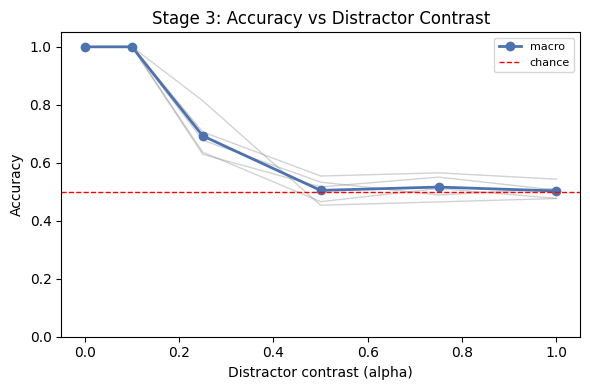

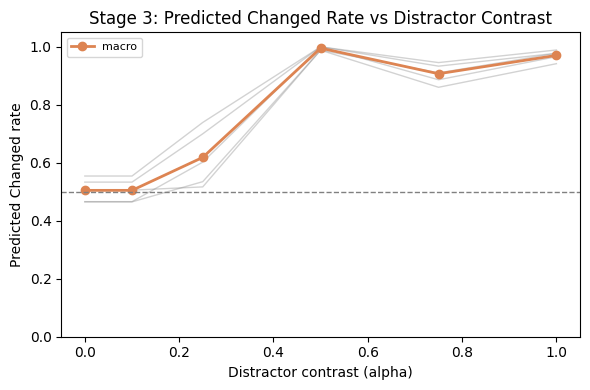

In [ ]:
# === S3-3: accuracy and predicted-Changed rate vs distractor contrast ===
# Plot 1: accuracy vs alpha
fig = plt.figure(figsize=(6, 4))
for v, sub in by_var_alpha.groupby("variant"):
    plt.plot(sub["alpha"], sub["accuracy"], color="grey", alpha=0.35, lw=1)
plt.plot(macro_alpha["alpha"], macro_alpha["accuracy_macro"], "o-", color="#4C72B0", lw=2, label="macro")
plt.axhline(0.5, ls="--", c="red", lw=1, label="chance")
plt.ylim(0, 1.05); plt.xlabel("Distractor contrast (alpha)"); plt.ylabel("Accuracy")
plt.title("Stage 3: Accuracy vs Distractor Contrast"); plt.legend(fontsize=8); plt.tight_layout()
fig.savefig(os.path.join(S3_PLT, "accuracy_vs_contrast.png"), dpi=DPI, bbox_inches="tight"); plt.show(); plt.close(fig)

# Plot 2: predicted-Changed rate vs alpha
fig = plt.figure(figsize=(6, 4))
for v, sub in by_var_alpha.groupby("variant"):
    plt.plot(sub["alpha"], sub["predicted_changed_rate"], color="grey", alpha=0.35, lw=1)
plt.plot(macro_alpha["alpha"], macro_alpha["predicted_changed_macro"], "o-", color="#DD8452", lw=2, label="macro")
plt.axhline(0.5, ls="--", c="grey", lw=1)
plt.ylim(0, 1.05); plt.xlabel("Distractor contrast (alpha)"); plt.ylabel("Predicted Changed rate")
plt.title("Stage 3: Predicted Changed Rate vs Distractor Contrast"); plt.legend(fontsize=8); plt.tight_layout()
fig.savefig(os.path.join(S3_PLT, "predicted_changed_vs_contrast.png"), dpi=DPI, bbox_inches="tight"); plt.show(); plt.close(fig)

**Final — Cell PKG: Zip all outputs and download**

In [ ]:
# === PKG: bundle everything into paper_outputs.zip and download ===
zip_base = "paper_outputs"
if os.path.exists(zip_base + ".zip"):
    os.remove(zip_base + ".zip")
shutil.make_archive(zip_base, "zip", PAPER_ROOT)
print(f"Created {zip_base}.zip ({round(os.path.getsize(zip_base + '.zip')/1e6, 2)} MB)")
try:
    from google.colab import files
    files.download(zip_base + ".zip")
except Exception as e:
    print("Auto-download unavailable:", e, "\nDownload it manually from the Colab file browser (left panel).")

Created paper_outputs.zip (0.89 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>